#### Import Modules 

In [40]:
import sys
sys.path.append('..')
from src.stock_data_loader import load_stock, fix_dtypes, handle_missing
from src.indicators import (
    add_moving_averages, add_rsi, add_macd, print_signals, print_financial_metrics, check_ma_signal, check_macd_signal
)
from src.visualizations import plot_all_indicators

###  Technical analysis pipeline 

 LOAD AND CLEAN DATA

In [41]:
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
all_stock_data = {}

for ticker in tickers:
    df = load_stock(ticker)
    df = fix_dtypes(df)
    df = handle_missing(df)
    all_stock_data[ticker] = df
    
    print(f"{ticker}: {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")

AAPL: 3774 rows, 2009-01-02 to 2023-12-29
AMZN: 3774 rows, 2009-01-02 to 2023-12-29
GOOG: 3774 rows, 2009-01-02 to 2023-12-29
META: 2923 rows, 2012-05-18 to 2023-12-29
NVDA: 3774 rows, 2009-01-02 to 2023-12-29


ADD TECHNICAL INDICATORS

In [42]:

for ticker, df in all_stock_data.items():
    df = add_moving_averages(df)
    df = add_rsi(df)
    df = add_macd(df)
    all_stock_data[ticker] = df
    print(f"Added indicators to {ticker}")

Added indicators to AAPL
Added indicators to AMZN
Added indicators to GOOG
Added indicators to META
Added indicators to NVDA


View Latest Values for Each Stock

In [43]:
for ticker, df in all_stock_data.items():
    print(f"\n{'='*60}")
    print(f"{ticker} - LATEST VALUES")
    print(f"{'='*60}")
    print(df[['Date', 'Close', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'MACD_signal']].tail(5).to_string())


AAPL - LATEST VALUES
           Date       Close      SMA_20      SMA_50        RSI      MACD  MACD_signal
3769 2023-12-22  191.788757  191.856618  183.572859  54.672784  2.633141     3.235256
3770 2023-12-26  191.243912  192.018094  183.858864  53.090049  2.304751     3.049155
3771 2023-12-27  191.342972  192.154308  184.149424  53.354446  2.029104     2.845145
3772 2023-12-28  191.768951  192.362839  184.479567  54.540999  1.823998     2.640915
3773 2023-12-29  190.728775  192.490633  184.814828  51.121347  1.559539     2.424640

AMZN - LATEST VALUES
           Date       Close      SMA_20    SMA_50        RSI      MACD  MACD_signal
3769 2023-12-22  153.419998  148.578999  141.2430  64.115558  3.135958     2.873052
3770 2023-12-26  153.410004  148.863000  141.7154  64.085644  3.118650     2.922172
3771 2023-12-27  153.339996  149.178500  142.1312  63.860893  3.063965     2.950530
3772 2023-12-28  153.380005  149.531499  142.5694  63.938728  2.989395     2.958303
3773 2023-12-29  151

GET TRADING SIGNALS FOR EACH STOCK

In [47]:
ticker = 'AAPL'
print_signals(df, ticker)


 MOVING AVERAGE FOR AAPL:
   Trend: UPTREND
   Action: HOLD

 RSI FOR AAPL:
   Status: NEUTRAL
   Action: HOLD

 MACD FOR AAPL:
   Momentum: BULLISH
   Action: HOLD


In [48]:
ticker = 'AMZN'
print_signals(df, ticker)


 MOVING AVERAGE FOR AMZN:
   Trend: UPTREND
   Action: HOLD

 RSI FOR AMZN:
   Status: NEUTRAL
   Action: HOLD

 MACD FOR AMZN:
   Momentum: BULLISH
   Action: HOLD


In [49]:
ticker = 'GOOG'
print_signals(df, ticker)


 MOVING AVERAGE FOR GOOG:
   Trend: UPTREND
   Action: HOLD

 RSI FOR GOOG:
   Status: NEUTRAL
   Action: HOLD

 MACD FOR GOOG:
   Momentum: BULLISH
   Action: HOLD


In [50]:
ticker = 'META'
print_signals(df, ticker)


 MOVING AVERAGE FOR META:
   Trend: UPTREND
   Action: HOLD

 RSI FOR META:
   Status: NEUTRAL
   Action: HOLD

 MACD FOR META:
   Momentum: BULLISH
   Action: HOLD


In [51]:
ticker = 'NVDA'
print_signals(df, ticker)


 MOVING AVERAGE FOR NVDA:
   Trend: UPTREND
   Action: HOLD

 RSI FOR NVDA:
   Status: NEUTRAL
   Action: HOLD

 MACD FOR NVDA:
   Momentum: BULLISH
   Action: HOLD


In [46]:
for ticker, df in all_stock_data.items():
    print_financial_metrics(df, ticker)


FINANCIAL METRICS: AAPL
Total Return:      6907.7%
Volatility:        28.6%
Max Drawdown:      -43.8%
Sharpe Ratio:      1.07

FINANCIAL METRICS: AMZN
Total Return:      5490.1%
Volatility:        34.7%
Max Drawdown:      -56.1%
Sharpe Ratio:      0.89

FINANCIAL METRICS: GOOG
Total Return:      1661.0%
Volatility:        27.5%
Max Drawdown:      -44.6%
Sharpe Ratio:      0.76

FINANCIAL METRICS: META
Total Return:      825.9%
Volatility:        40.1%
Max Drawdown:      -76.7%
Sharpe Ratio:      0.63

FINANCIAL METRICS: NVDA
Total Return:      24691.8%
Volatility:        45.9%
Max Drawdown:      -66.3%
Sharpe Ratio:      0.99


#### ALL STOCKS COMPARISON TABLE

In [45]:


print("\n" + "="*90)
print(f"{'Ticker':<8} {'Price':<10} {'SMA_20':<10} {'SMA_50':<10} {'Trend':<10} {'RSI':<6} {'MACD':<8}")
print("="*90)

for ticker, df in all_stock_data.items():
    last = df.iloc[-1]
    trend = check_ma_signal(df)['trend']
    rsi_val = last['RSI']
    macd_status = check_macd_signal(df)['momentum'][0]  # 'B' or 'b' for Bullish/Bearish
    
    print(f"{ticker:<8} ${last['Close']:<9.2f} ${last['SMA_20']:<9.2f} ${last['SMA_50']:<9.2f} {trend:<10} {rsi_val:<6.0f} {macd_status:<8}")


Ticker   Price      SMA_20     SMA_50     Trend      RSI    MACD    
AAPL     $190.73    $192.49    $184.81    UPTREND    51     B       
AMZN     $151.94    $149.82    $143.05    UPTREND    59     B       
GOOG     $139.97    $135.98    $134.06    UPTREND    59     B       
META     $351.79    $336.87    $326.26    UPTREND    64     B       
NVDA     $49.50     $48.05     $46.66     UPTREND    58     B       


### Visualize each stocks

#### Plot AAPL


##################################################
TECHNICAL ANALYSIS: AAPL
##################################################

 PLOT 1: Price Chart with Moving Averages


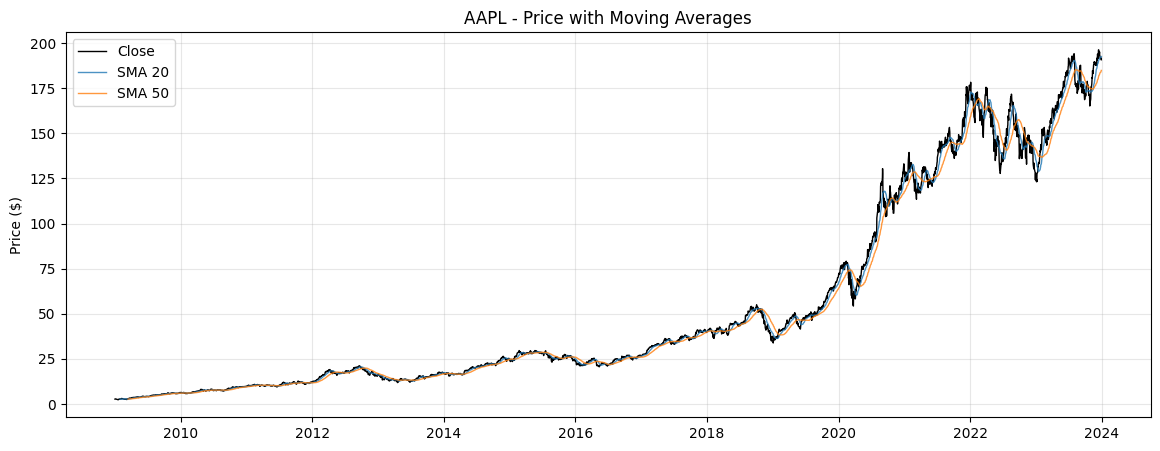


 PLOT 2: RSI (Relative Strength Index)


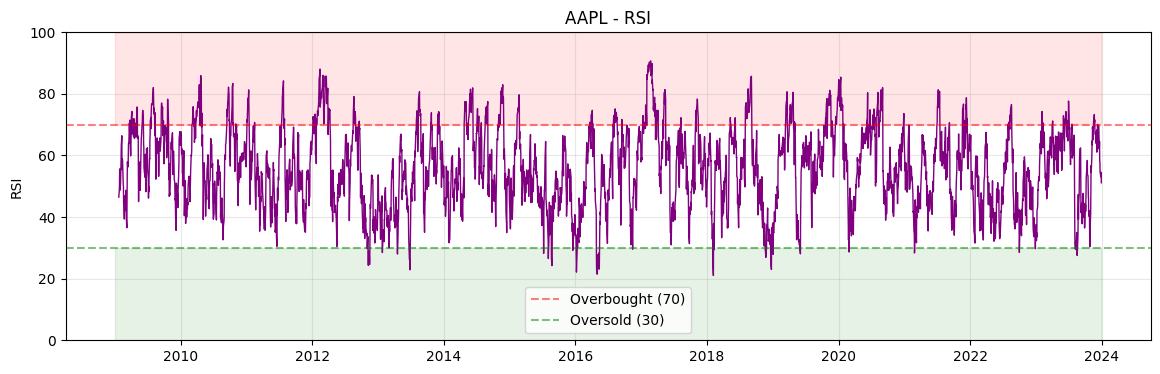


 PLOT for MACD (Moving Average Convergence Divergence)


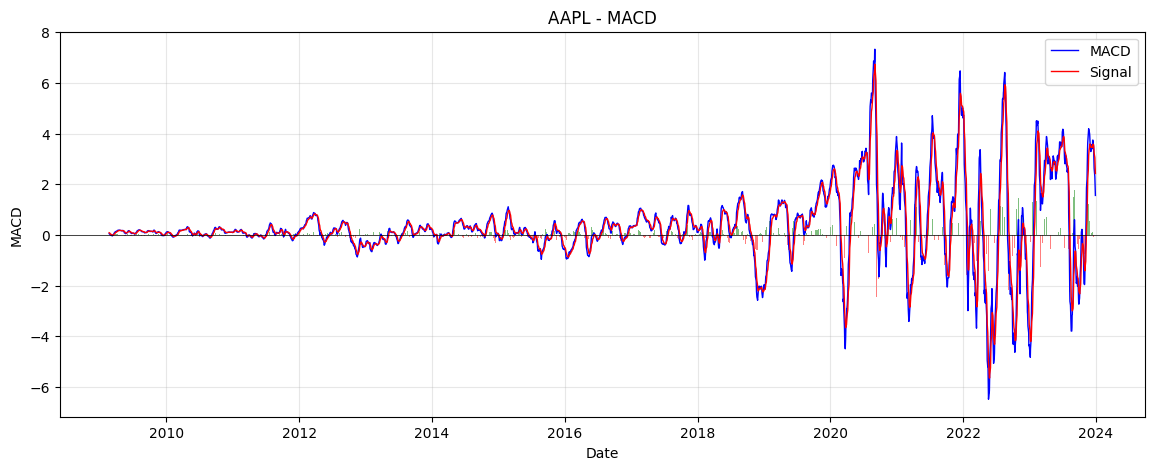

In [18]:
plot_all_indicators(df, ticker)

#### plot AMZN


##################################################
TECHNICAL ANALYSIS: AMZN
##################################################

 PLOT 1: Price Chart with Moving Averages


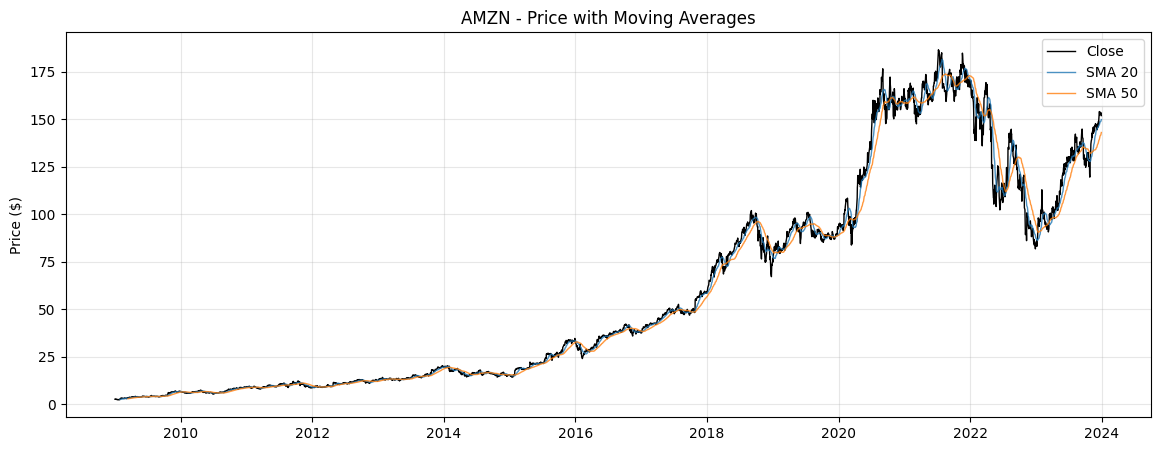


 PLOT 2: RSI (Relative Strength Index)


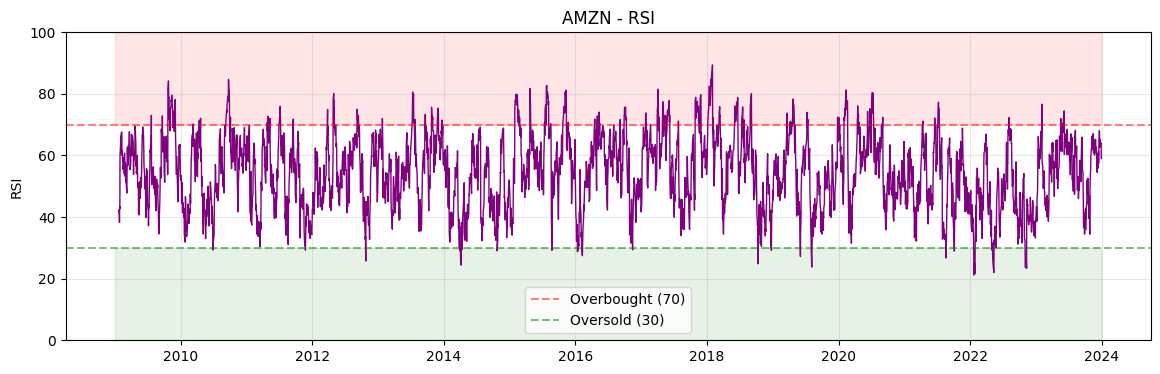


 PLOT for MACD (Moving Average Convergence Divergence)


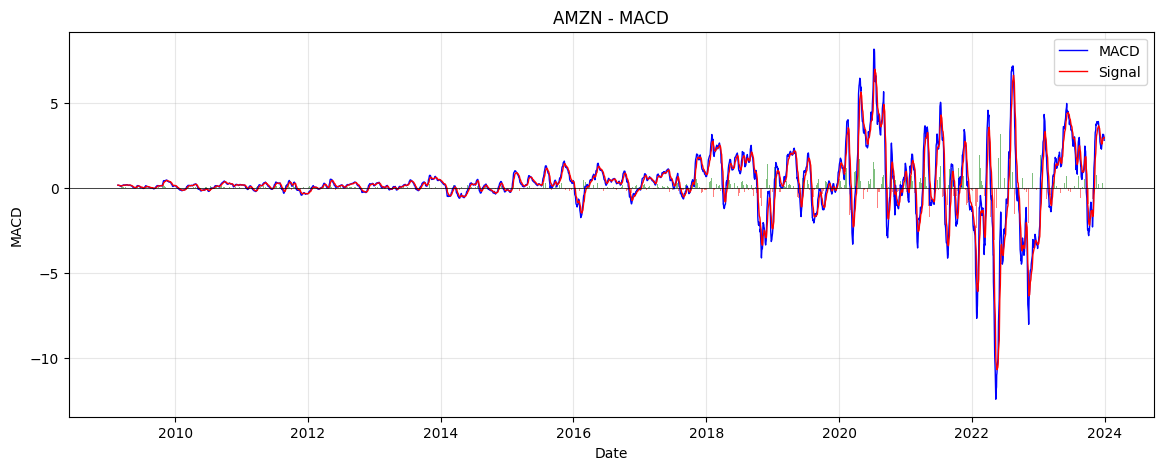

In [31]:
plot_all_indicators(all_stock_data['AMZN'], 'AMZN')

#### plot GOOG


##################################################
TECHNICAL ANALYSIS: GOOG
##################################################

 PLOT 1: Price Chart with Moving Averages


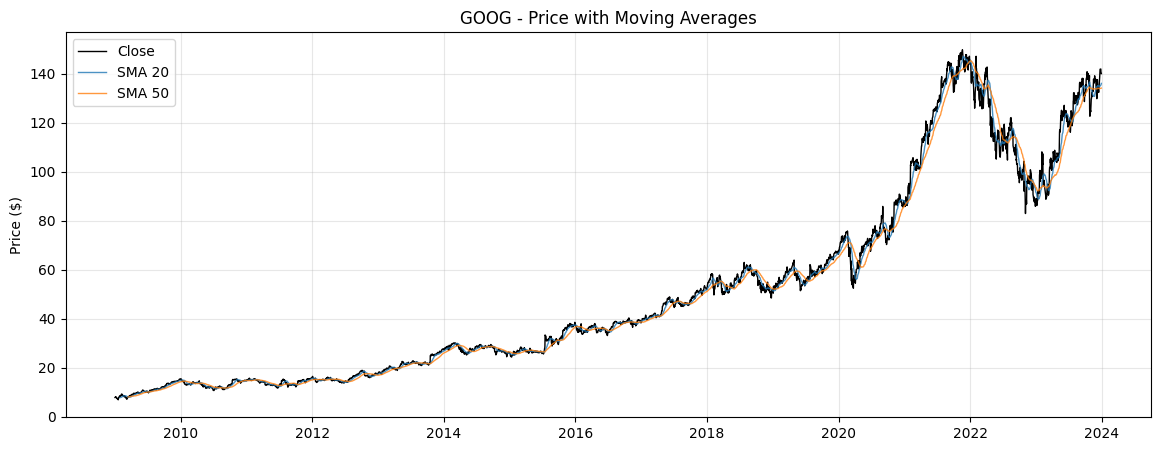


 PLOT 2: RSI (Relative Strength Index)


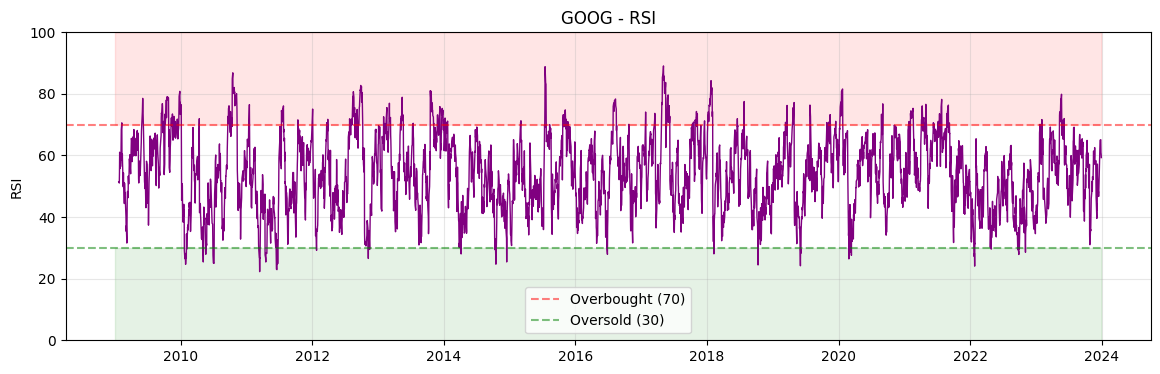


 PLOT for MACD (Moving Average Convergence Divergence)


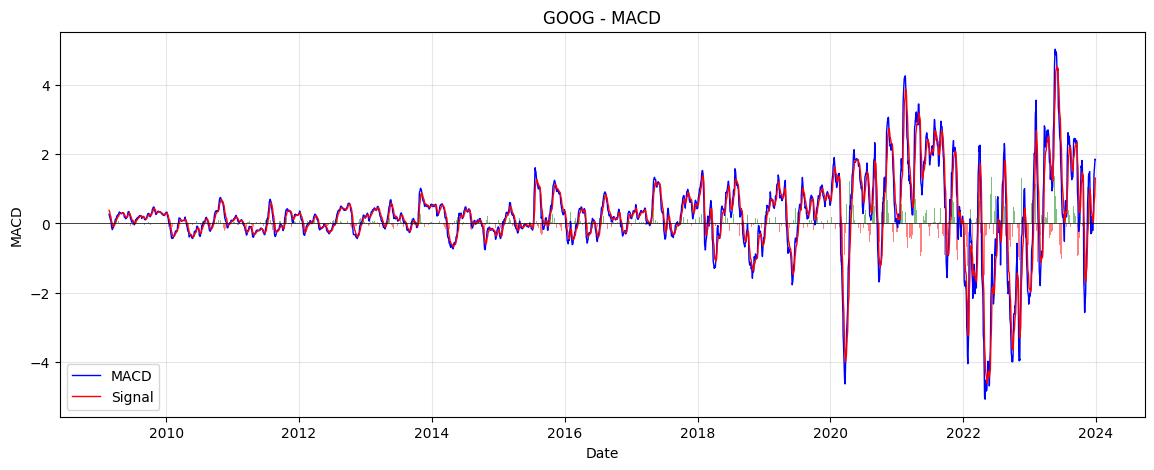

In [32]:
plot_all_indicators(all_stock_data['GOOG'], 'GOOG')

#### plot META


##################################################
TECHNICAL ANALYSIS: META
##################################################

 PLOT 1: Price Chart with Moving Averages


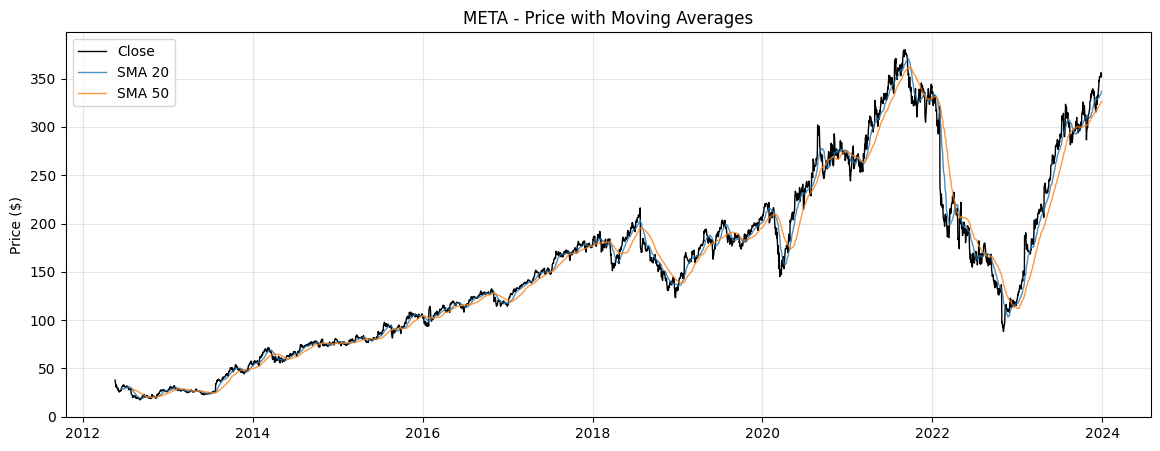


 PLOT 2: RSI (Relative Strength Index)


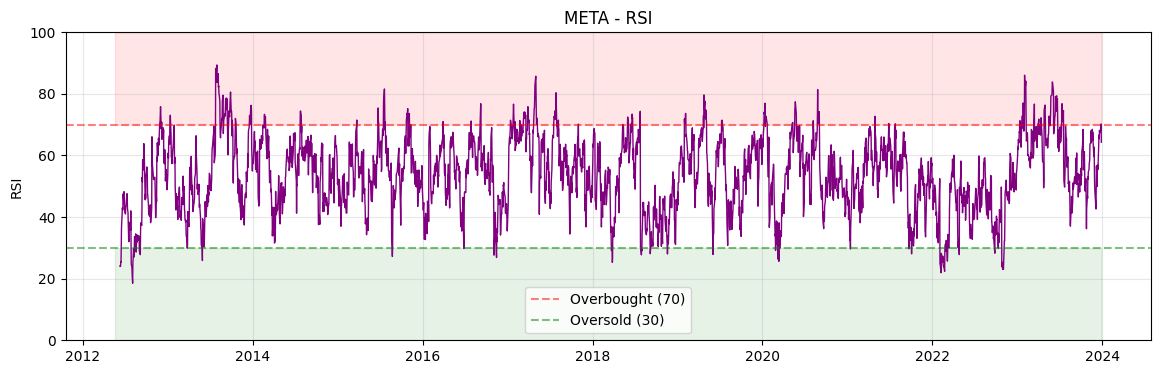


 PLOT for MACD (Moving Average Convergence Divergence)


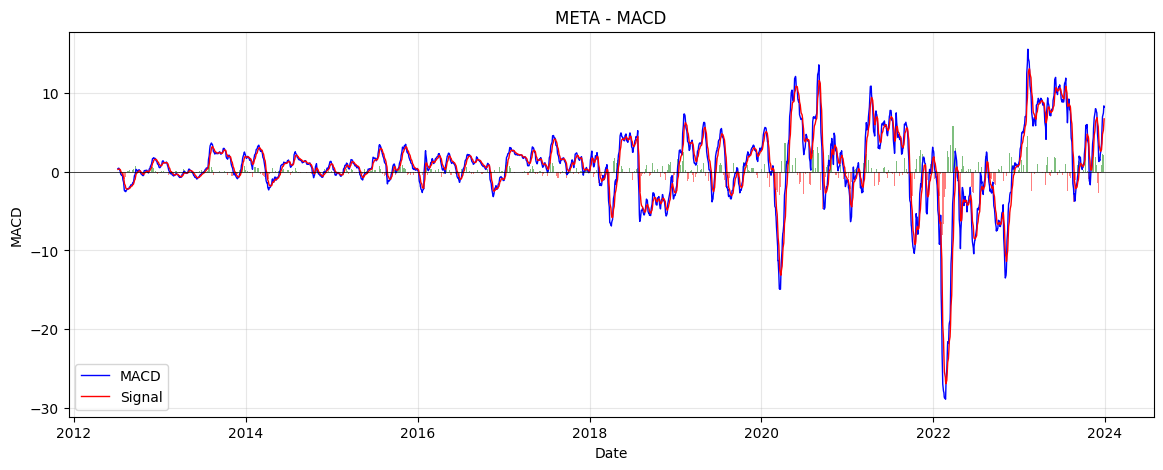

In [33]:
plot_all_indicators(all_stock_data['META'], 'META')

#### plot NVDA


##################################################
TECHNICAL ANALYSIS: NVDA
##################################################

 PLOT 1: Price Chart with Moving Averages


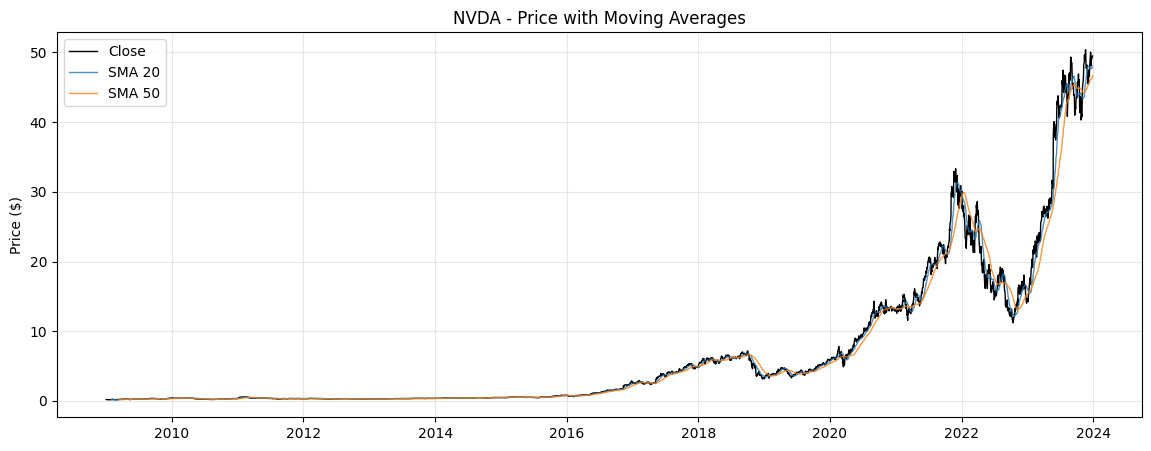


 PLOT 2: RSI (Relative Strength Index)


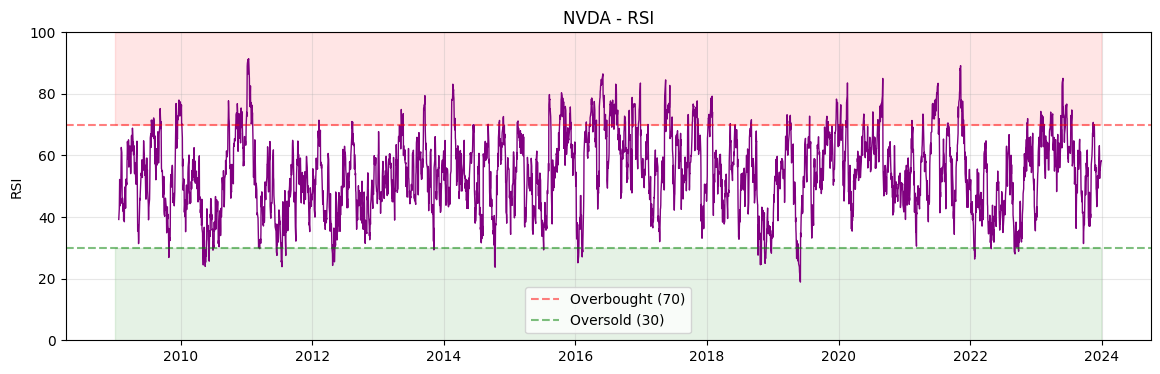


 PLOT for MACD (Moving Average Convergence Divergence)


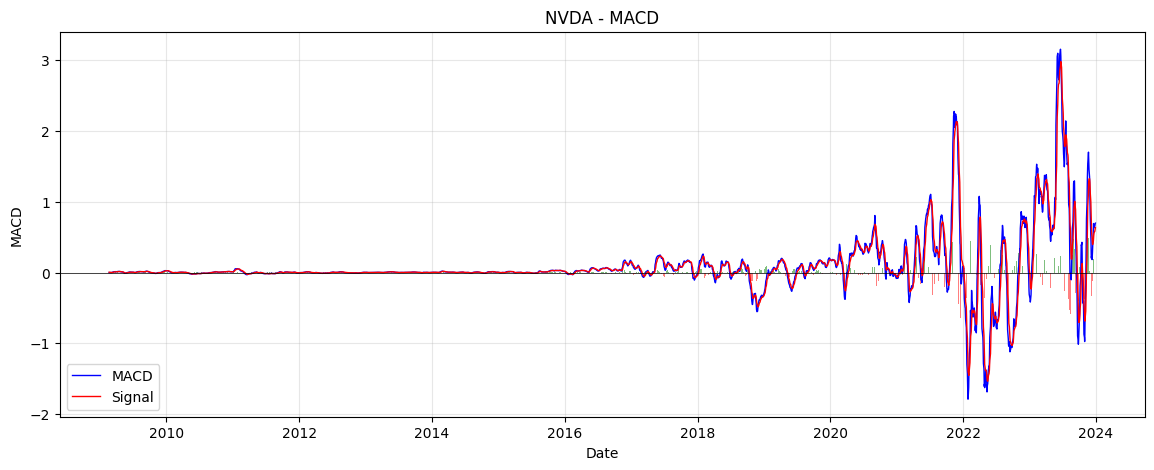

In [34]:
plot_all_indicators(all_stock_data['NVDA'], 'NVDA')